28


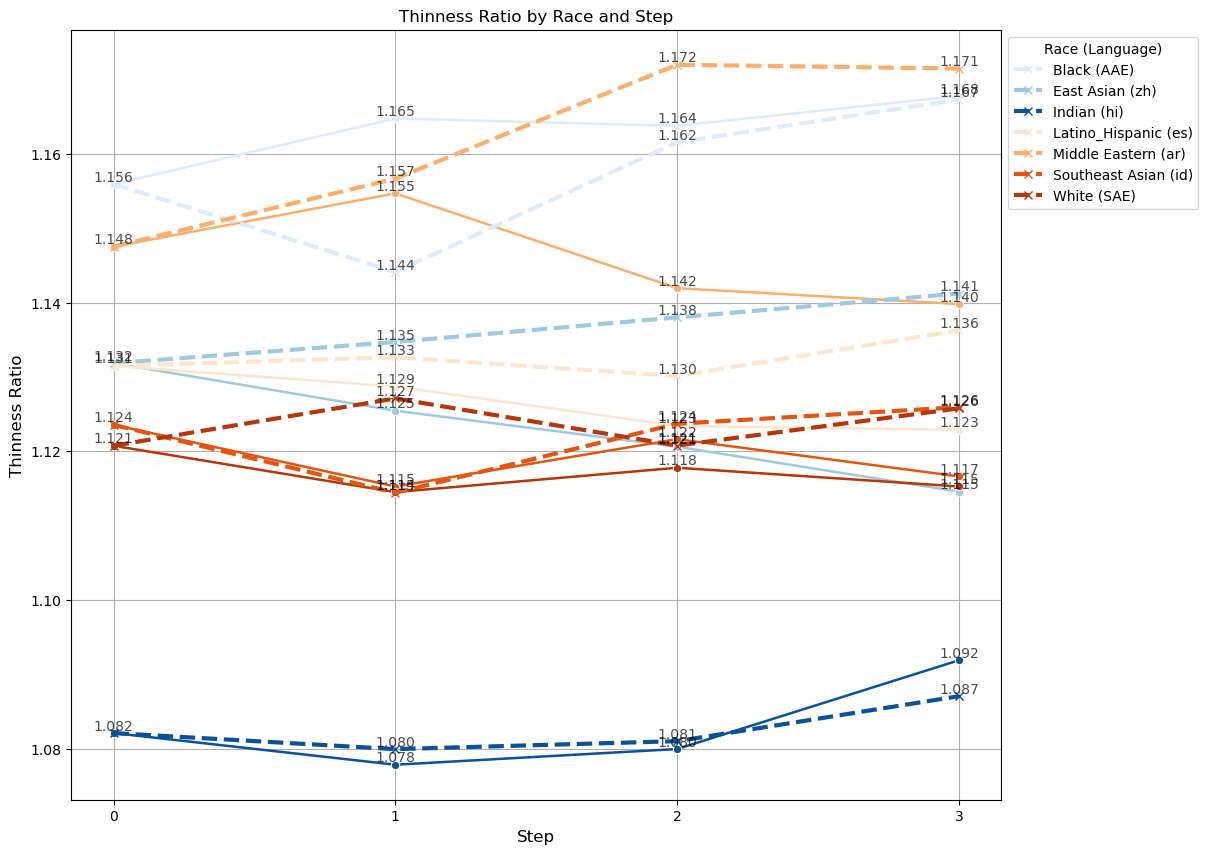

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取第一个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data_1 = pd.read_csv(file_path_1)

# 读取第二个数据文件
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data_2 = pd.read_csv(file_path_2)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores_1 = data_1.groupby(['Step', 'race']).agg({'thinness_ratio': 'mean'}).reset_index()
mean_scores_2 = data_2.groupby(['Step', 'race']).agg({'thinness_ratio': 'mean'}).reset_index()

# 创建种族和语言的对应关系
race_languthinness_ratio_mapping = {
    'White': 'SAE',
    'Black': 'AAE',
    'Middle Eastern': 'ar',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es',
    'East Asian': 'zh'
}

# 添加语言列
mean_scores_1['Languthinness_ratio'] = mean_scores_1['race'].map(race_languthinness_ratio_mapping)
mean_scores_2['Languthinness_ratio'] = mean_scores_2['race'].map(race_languthinness_ratio_mapping)
cmap = plt.get_cmap('tab20c')
#color = [cmap(i) for i in range(0, 20, 2)][:7]
color = ['#021b7e', '#9fa3ae', '#8fdbfb', '#e6520a', '#ccbae0', '#b3102b', '#9770b6']
color = ['#ece644', '#efab6d', '#7f7db5', '#a5ce9d', '#08519c', '#a2c8dd', ]
color=['#deebfc', '#9ecae1', '#08519c','#fee6ce', '#fdae6b', '#e6550d','#b73508'] 
# 绘图
plt.figure(figsize=(12, 10))

# 绘制第一个数据集
sns.lineplot(data=mean_scores_1, x='Step', y='thinness_ratio', hue='race', marker='o', linestyle='-', palette=color, legend=False,linewidth=1.8)

# 绘制第二个数据集
for race in mean_scores_2['race'].unique():
    subset = mean_scores_2[mean_scores_2['race'] == race]
    plt.plot(subset['Step'], subset['thinness_ratio'], marker='x', linestyle='--', color=sns.color_palette(color)[list(mean_scores_1['race'].unique()).index(race)], label=f"{race} ({subset['Languthinness_ratio'].iloc[0]})",linewidth=3)

# 添加每个点的数值标签，稍微调整位置
for i in range(len(mean_scores_1)):
    plt.text(mean_scores_1['Step'][i], mean_scores_1['thinness_ratio'][i],
             f"{mean_scores_1['thinness_ratio'][i]:.3f}", 
             fontsize=10, ha='center', va='bottom', alpha=0.7)
print(len(mean_scores_2))
for i in range(7,28):
    plt.text(mean_scores_2['Step'][i], mean_scores_2['thinness_ratio'][i] ,
             f"{mean_scores_2['thinness_ratio'][i]:.3f}", 
             fontsize=10, ha='center', va='bottom', alpha=0.7)

# 设置图例格式为“种族（语言）”，并将图例移到右侧
plt.legend(title='Race (Language)', loc='upper left', bbox_to_anchor=(1, 1))

plt.title('Thinness Ratio by Race and Step')
plt.xlabel('Step',fontsize=12)
plt.ylabel('Thinness Ratio',fontsize=12)
plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
plt.grid()
plt.show()


In [21]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对 Step = 0、1、2、3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 计算每个步骤的平均数
        mean_values = subset.groupby('Step')['thinness_ratio'].mean().reset_index()
        
        # 保留仅包含 Step 0、1、2、3 的数据
        step_subset = subset[subset['Step'].isin([0, 1, 2, 3])]
        
        if step_subset['Step'].nunique() >= 2:  # 如果有两个或更多 Step
            # 对每对步骤之间进行 Kruskal-Wallis H 检验
            steps = [0, 1, 2, 3]
            for i in range(len(steps)):
                for j in range(i + 1, len(steps)):
                    step_i = steps[i]
                    step_j = steps[j]
                    
                    # 筛选步骤数据
                    step_i_data = step_subset[step_subset['Step'] == step_i]['thinness_ratio']
                    step_j_data = step_subset[step_subset['Step'] == step_j]['thinness_ratio']
                    
                    # 如果两个步骤都有数据，则进行检验
                    if len(step_i_data) > 0 and len(step_j_data) > 0:
                        kruskal_stat, p_value = kruskal(step_i_data, step_j_data)
                        print(f"\nKruskal-Wallis H Test for {race_group} (Step {step_i} vs Step {step_j}):")
                        print(f"H-statistic: {kruskal_stat}, p-value: {p_value}")
                        
                        # 如果有显著性差异，进行 Dunn's Test 事后检验
                        if p_value < 0.05:
                            dunn_test = sp.posthoc_dunn(step_subset, val_col='thinness_ratio', group_col='Step', p_adjust='bonferroni')
                            print(f"\nDunn's Test for {race_group} (Step {step_i} vs Step {step_j}):")
                            print(dunn_test)

# 分别对两个文件进行分析
perform_tests(data_1, "Filter_OpenB.csv")
perform_tests(data_2, "Filter_StabB.csv")



Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 2):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 3):
H-statistic: 0.05142857142857338, p-value: 0.8205958397554376

Kruskal-Wallis H Test for Middle Eastern (Step 2 vs Step 3):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for East Asian (Step 1 vs Step 2):
H-statistic: 0.0, p-value: 1.0

Kruskal-Wallis H Test for East Asian (Step 1 vs Step 3):
H-statistic: 0.8228571428571456, p-value: 0.36434612663355215

Kruskal-Wallis H Test for East Asian (Step 2 vs Step 3):
H-statistic: 0.4628571428571391, p-value: 0.49629170223109464

Kruskal-Wallis H Test for Black (Step 1 vs Step 2):
H-statistic: 0.005714285714276457, p-value: 0.939742989577122

Kruskal-Wallis H Test for Black (Step 1 vs Step 3):
H-statistic: 0.005714285714276457, p-value: 0.939742989577122

Kruskal-Wallis H Test for Black (Ste

In [2]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对 Step = 0 和 Step = 1、Step = 0 和 Step = 3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 仅筛选 Step 0 和 Step 1
        step_0_1_subset = subset[subset['Step'].isin([0, 1])]
        
        if step_0_1_subset['Step'].nunique() == 2:  # 如果数据中有两个 Step
            kruskal_stat_0_1, p_value_0_1 = kruskal(step_0_1_subset[step_0_1_subset['Step'] == 0]['thinness_ratio'], 
                                                    step_0_1_subset[step_0_1_subset['Step'] == 1]['thinness_ratio'])
            print(f"\nKruskal-Wallis H Test for {race_group} (Step 0 vs Step 1):")
            print(f"H-statistic: {kruskal_stat_0_1}, p-value: {p_value_0_1}")
            
            # 如果有显著性差异，进行 Dunn's Test 事后检验
            if p_value_0_1 < 0.05:
                dunn_0_1 = sp.posthoc_dunn(step_0_1_subset, val_col='thinness_ratio', group_col='Step', p_adjust='bonferroni')
                print(f"\nDunn's Test for {race_group} (Step 0 vs Step 1):")
                print(dunn_0_1)
        
        # 仅筛选 Step 0 和 Step 3
        step_0_3_subset = subset[subset['Step'].isin([0, 3])]
        
        if step_0_3_subset['Step'].nunique() == 2:  # 如果数据中有两个 Step
            kruskal_stat_0_3, p_value_0_3 = kruskal(step_0_3_subset[step_0_3_subset['Step'] == 0]['thinness_ratio'], 
                                                    step_0_3_subset[step_0_3_subset['Step'] == 3]['thinness_ratio'])
            print(f"\nKruskal-Wallis H Test for {race_group} (Step 0 vs Step 3):")
            print(f"H-statistic: {kruskal_stat_0_3}, p-value: {p_value_0_3}")
            
            # 如果有显著性差异，进行 Dunn's Test 事后检验
            if p_value_0_3 < 0.05:
                dunn_0_3 = sp.posthoc_dunn(step_0_3_subset, val_col='thinness_ratio', group_col='Step', p_adjust='bonferroni')
                print(f"\nDunn's Test for {race_group} (Step 0 vs Step 3):")
                print(dunn_0_3)

# 分别对两个文件进行分析
perform_tests(data_1, "Filter_OpenB.csv")
perform_tests(data_2, "Filter_StabB.csv")



Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 1):
H-statistic: 0.0, p-value: 1.0

Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 3):
H-statistic: 0.005714285714276457, p-value: 0.939742989577122

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 1):
H-statistic: 0.3657142857142901, p-value: 0.5453496680111212

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 3):
H-statistic: 1.6514285714285677, p-value: 0.19876460637323198

Kruskal-Wallis H Test for Black (Step 0 vs Step 1):
H-statistic: 0.1428571428571388, p-value: 0.7054569861112774

Kruskal-Wallis H Test for Black (Step 0 vs Step 3):
H-statistic: 0.4628571428571391, p-value: 0.49629170223109464

Kruskal-Wallis H Test for Latino_Hispanic (Step 0 vs Step 1):
H-statistic: 0.05142857142857338, p-value: 0.8205958397554376

Kruskal-Wallis H Test for Latino_Hispanic (Step 0 vs Step 3):
H-statistic: 0.0, p-value: 1.0

Kruskal-Wallis H Test for Southeast Asian (Step 0 vs Step 1):
H

d:\Anaconda3\envs\pytorch\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


                     thinness_ratio                                          \
                              count      mean       std       min       25%   
race            Step                                                          
Black           0              10.0  1.155951  0.049195  1.084189  1.108553   
                1              10.0  1.164774  0.065430  1.079720  1.109066   
                2              10.0  1.163789  0.057743  1.078002  1.110656   
                3              10.0  1.167815  0.061318  1.079337  1.111958   
East Asian      0              10.0  1.131851  0.058187  1.022527  1.106277   
                1              10.0  1.125462  0.050762  1.016471  1.115520   
                2              10.0  1.120618  0.047015  1.012981  1.098213   
                3              10.0  1.114563  0.049354  1.007206  1.100443   
Indian          0              10.0  1.082087  0.084582  0.937341  1.032635   
                1              10.0  1.077829  0.068

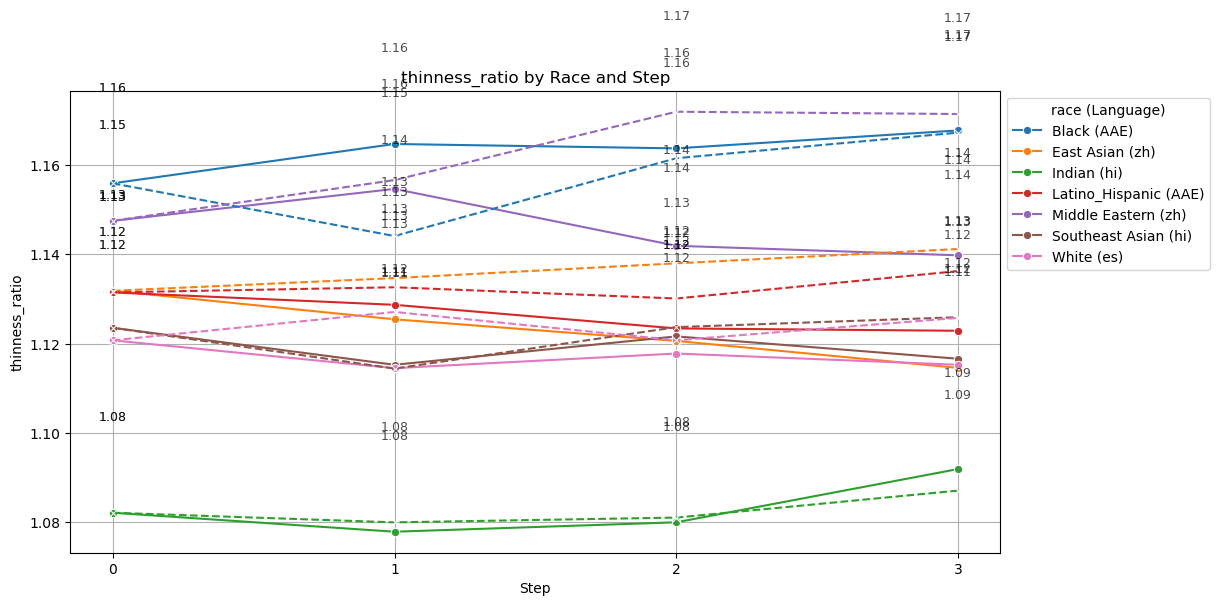

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
'''
    OA/SD
'''
# 读取第一个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data_1 = pd.read_csv(file_path_1)

# 读取第二个数据文件
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data_2 = pd.read_csv(file_path_2)

# 描述性统计，按种族和递进步骤分类
description_1 = data_1.groupby(['race', 'Step'])[['thinness_ratio']].describe()
description_2 = data_2.groupby(['race', 'Step'])[['thinness_ratio']].describe()
print(description_1)
print(description_2)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores_1 = data_1.groupby(['Step', 'race']).agg({
    'thinness_ratio': 'mean',
}).reset_index()

mean_scores_2 = data_2.groupby(['Step', 'race']).agg({
    'thinness_ratio': 'mean',
}).reset_index()

# 创建种族和语言的对应关系
race_language_mapping = {
    'Middle Eastern': 'ar',
    'White': 'SAE',
    'Black': 'AAE',
    'East Asian': 'zh',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es'
}

# 添加语言列
mean_scores_1['Language'] = mean_scores_1['race'].map(race_language_mapping)
mean_scores_2['Language'] = mean_scores_2['race'].map(race_language_mapping)

# 绘图
plt.figure(figsize=(12, 6))

# 绘制第一个数据集
sns.lineplot(data=mean_scores_1, x='Step', y='thinness_ratio', hue='race', marker='o', linestyle='-', palette='tab10')

# 绘制第二个数据集
sns.lineplot(data=mean_scores_2, x='Step', y='thinness_ratio', hue='race', marker='x', linestyle='--', palette='tab10', legend=False)

# 添加每个点的数值标签，稍微调整位置
for i in range(len(mean_scores_1)):
    plt.text(mean_scores_1['Step'][i], mean_scores_1['thinness_ratio'][i] + 0.02,
             f"{mean_scores_1['thinness_ratio'][i]:.2f}", 
             fontsize=9, ha='center', va='bottom', alpha=0.7)

for i in range(len(mean_scores_2)):
    plt.text(mean_scores_2['Step'][i], mean_scores_2['thinness_ratio'][i] + 0.02,
             f"{mean_scores_2['thinness_ratio'][i]:.2f}", 
             fontsize=9, ha='center', va='bottom', alpha=0.7)

# 设置图例格式为“种族（语言）”，并将图例移到右侧
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, [f"{labels[i]} ({mean_scores_1['Language'][i]})" for i in range(len(labels)//2)] +
                     [f"{labels[i]} ({mean_scores_2['Language'][i - len(labels)//2]})" for i in range(len(labels)//2, len(labels))], 
           title='race (Language)', loc='upper left', bbox_to_anchor=(1, 1))

plt.title('thinness_ratio by Race and Step')
plt.xlabel('Step')
plt.ylabel('thinness_ratio')
plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
plt.grid()
plt.show()


In [2]:
#Open
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['thinness_ratio']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
for score_column, result in normality_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足正态分布的假设。")
    else:
        print("  -> 数据不满足正态分布的假设。")

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
for score_column, result in levene_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足方差齐性的假设。")
    else:
        print("  -> 数据不满足方差齐性的假设。")

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")


Normality Test Results:
thinness_ratio: W-statistic = 0.9838, p-value = 0.0029
  -> 数据不满足正态分布的假设。

Levene's Test for Homogeneity of Variances Results:
thinness_ratio: W-statistic = 1.6366, p-value = 0.1371
  -> 数据满足方差齐性的假设。

Analyzing thinness_ratio:
Kruskal-Wallis H Test Results: H-statistic = 28.1644, p-value = 0.0001
  -> 结果显著，说明不同种族之间的年龄存在差异。


In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['thinness_ratio']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
               H-statistic              Test   p-value
thinness_ratio   28.164365  Kruskal-Wallis H  0.000087

Dunn's Test Results for thinness_ratio:
                        Black  East Asian        Indian  Latino_Hispanic  \
Black            1.000000e+00    0.010512  3.697572e-07         0.011972   
East Asian       1.051187e-02    1.000000  1.155724e-02         0.963657   
Indian           3.697572e-07    0.011557  1.000000e+00         0.010142   
Latino_Hispanic  1.197243e-02    0.963657  1.014208e-02         1.000000   
Middle Eastern   1.193565e-01    0.316807  4.212144e-04         0.339337   
Southeast Asian  2.808720e-03    0.667624  3.608478e-02         0.634804   
White            2.557107e-02    0.744533  4.354932e-03         0.779254   

                 Middle Eastern  Southeast Asian     White  
Black                  0.119357         0.002809  0.025571  
East Asian             0.316807         0.667624  0.744533  
Indian                

In [4]:
#Stab
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['thinness_ratio']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
for score_column, result in normality_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足正态分布的假设。")
    else:
        print("  -> 数据不满足正态分布的假设。")

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
for score_column, result in levene_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足方差齐性的假设。")
    else:
        print("  -> 数据不满足方差齐性的假设。")

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")


Normality Test Results:
thinness_ratio: W-statistic = 0.9897, p-value = 0.0444
  -> 数据不满足正态分布的假设。

Levene's Test for Homogeneity of Variances Results:
thinness_ratio: W-statistic = 3.1110, p-value = 0.0058
  -> 数据不满足方差齐性的假设。

Analyzing thinness_ratio:
Kruskal-Wallis H Test Results: H-statistic = 25.9579, p-value = 0.0002
  -> 结果显著，说明不同种族之间的年龄存在差异。


In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['thinness_ratio']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
               H-statistic              Test   p-value
thinness_ratio   25.957864  Kruskal-Wallis H  0.000227

Dunn's Test Results for thinness_ratio:
                    Black  East Asian    Indian  Latino_Hispanic  \
Black            1.000000    0.361415  0.000014         0.062418   
East Asian       0.361415    1.000000  0.000592         0.341786   
Indian           0.000014    0.000592  1.000000         0.012968   
Latino_Hispanic  0.062418    0.341786  0.012968         1.000000   
Middle Eastern   0.752906    0.549932  0.000055         0.121501   
Southeast Asian  0.016782    0.139200  0.050404         0.597406   
White            0.167145    0.639239  0.003012         0.629891   

                 Middle Eastern  Southeast Asian     White  
Black                  0.752906         0.016782  0.167145  
East Asian             0.549932         0.139200  0.639239  
Indian                 0.000055         0.050404  0.003012  
Latino_Hispanic        0.

In [ ]:
'''加入thinness_ratio'''

In [2]:
'''5.17'''
import pandas as pd
import numpy as np

file_path=r'd:\Users\AAA\Desktop\517\face++\processed\Processed_Open.csv'
# 读取 Excel 文件
df = pd.read_csv(file_path) 

def parse_landmarks(landmark_dict):
    # 直接返回字典格式的关键点数据
    return eval(landmark_dict)  # 使用 eval() 来将字符串转换为字典

df['Landmarks'] = df['Landmarks'].apply(parse_landmarks)

def calculate_thinness_ratio(keypoints):
    # 获取左上角、右上角和下巴的坐标
    left_top = np.array([keypoints['contour_left1']['x'], keypoints['contour_left1']['y']])
    right_top = np.array([keypoints['contour_right1']['x'], keypoints['contour_right1']['y']])
    chin = np.array([keypoints['contour_chin']['x'], keypoints['contour_chin']['y']])
    
    # 计算面部高度
    middle_top_y = (left_top[1] + right_top[1]) / 2
    face_height = abs(chin[1] - middle_top_y)  # 纵坐标差值取绝对值

    # 计算面部轮廓平均宽度
    left_widths = []
    right_widths = []
    
    for i in range(1, 17):
        left_point = np.array([keypoints[f'contour_left{i}']['x'], keypoints[f'contour_left{i}']['y']])
        right_point = np.array([keypoints[f'contour_right{i}']['x'], keypoints[f'contour_right{i}']['y']])
        left_widths.append(left_point[0])
        right_widths.append(right_point[0])
    
    average_width = abs(np.mean(left_widths) - np.mean(right_widths))  # 计算宽度差的绝对值

    # 计算瘦削值
    if average_width != 0:  # 避免除以零
        thinness_value = face_height / average_width
    else:
        thinness_value = None  # 处理边界情况

    return thinness_value

# 计算每行的瘦削值
df['thinness_ratio'] = df['Landmarks'].apply(calculate_thinness_ratio)

# 输出结果
print(len(df[['thinness_ratio']]))
df.to_csv(file_path,index=False)


1540


In [ ]:
'''BDS版'''

In [ ]:
import pandas as pd
import numpy as np

file_path=r'd:\Users\AAA\Desktop\face++\StabB.csv'
# 读取 Excel 文件
df = pd.read_csv(file_path) 

def parse_landmarks(landmark_dict):
    # 直接返回字典格式的关键点数据
    return eval(landmark_dict)  # 使用 eval() 来将字符串转换为字典

df['Landmarks'] = df['Landmarks'].apply(parse_landmarks)

def calculate_thinness_ratio(keypoints):
    # 获取左上角、右上角和下巴的坐标
    left_top = np.array([keypoints['contour_left1']['x'], keypoints['contour_left1']['y']])
    right_top = np.array([keypoints['contour_right1']['x'], keypoints['contour_right1']['y']])
    chin = np.array([keypoints['contour_chin']['x'], keypoints['contour_chin']['y']])
    
    # 计算面部高度
    middle_top_y = (left_top[1] + right_top[1]) / 2
    face_height = abs(chin[1] - middle_top_y)  # 纵坐标差值取绝对值

    # 计算面部轮廓平均宽度
    left_widths = []
    right_widths = []
    
    for i in range(1, 17):
        left_point = np.array([keypoints[f'contour_left{i}']['x'], keypoints[f'contour_left{i}']['y']])
        right_point = np.array([keypoints[f'contour_right{i}']['x'], keypoints[f'contour_right{i}']['y']])
        left_widths.append(left_point[0])
        right_widths.append(right_point[0])
    
    average_width = abs(np.mean(left_widths) - np.mean(right_widths))  # 计算宽度差的绝对值

    # 计算瘦削值
    if average_width != 0:  # 避免除以零
        thinness_value = face_height / average_width
    else:
        thinness_value = None  # 处理边界情况

    return thinness_value

# 计算每行的瘦削值
df['thinness_ratio'] = df['Landmarks'].apply(calculate_thinness_ratio)

# 输出结果
print(len(df[['thinness_ratio']]))
df.to_csv(file_path,index=False)


1540


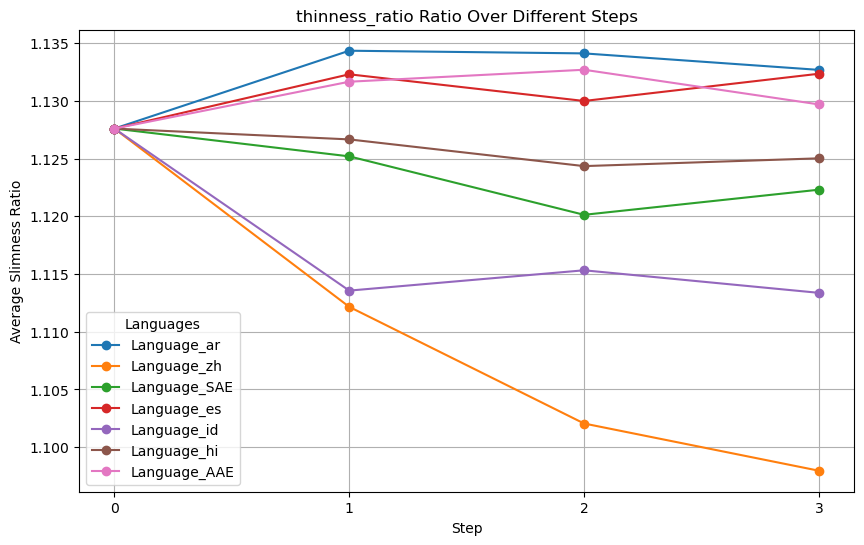

   Language_ar  Language_zh  Language_SAE  Language_es  Language_id  \
0     1.127603     1.127603      1.127603     1.127603     1.127603   
1     1.134350     1.112153      1.125195     1.132306     1.113560   
2     1.134118     1.102044      1.120129     1.129995     1.115321   
3     1.132689     1.097952      1.122306     1.132355     1.113367   

   Language_hi  Language_AAE  
0     1.127603      1.127603  
1     1.126665      1.131664  
2     1.124350      1.132701  
3     1.125024      1.129697  


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\OpenB.csv'  # 替换为实际路径
df = pd.read_csv(file_path)

languages = ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi', 'Language_AAE']

# 创建空的DataFrame来存储结果
results = {lang: [] for lang in languages}

# 循环每个语言，分别计算每个递进层次的瘦削比平均值
for step in range(4):  # 遍历0, 1, 2, 3步
    for lang in languages:
        # 过滤出该语言且递进层次为step的数据
        if step == 0:
            # 递进层次为0的图像，所有语言共享相同的原图
            filtered_data = df[df['Step'] == 0]
        else:
            # 递进层次不为0时，只筛选特定语言的数据
            filtered_data = df[(df[lang] == 1) & (df['Step'] == step)]
        
        # 计算瘦削比的平均值
        mean_slimness = filtered_data['thinness_ratio'].mean()
        results[lang].append(mean_slimness)

# 转换结果为DataFrame
result_df = pd.DataFrame(results, index=[0, 1, 2, 3])

# 可视化结果
plt.figure(figsize=(10, 6))
for lang in languages:
    plt.plot(result_df.index, result_df[lang], marker='o', label=lang)

plt.title('thinness_ratio Ratio Over Different Steps')
plt.xlabel('Step')
plt.ylabel('Average Slimness Ratio')
plt.xticks([0, 1, 2, 3])
plt.legend(title='Languages')
plt.grid(True)
plt.show()

# 输出结果表格
print(result_df)


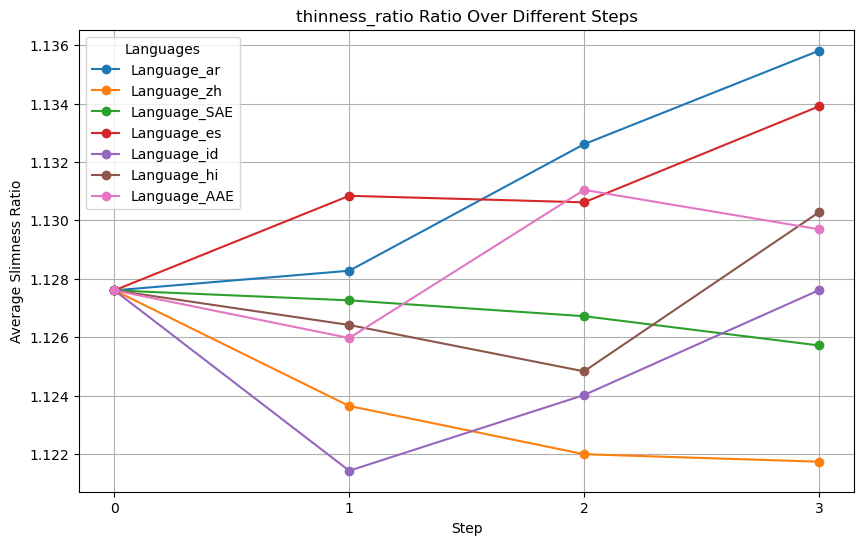

   Language_ar  Language_zh  Language_SAE  Language_es  Language_id  \
0     1.127603     1.127603      1.127603     1.127603     1.127603   
1     1.128275     1.123644      1.127262     1.130841     1.121428   
2     1.132608     1.121994      1.126719     1.130617     1.124020   
3     1.135808     1.121738      1.125718     1.133902     1.127609   

   Language_hi  Language_AAE  
0     1.127603      1.127603  
1     1.126418      1.125971  
2     1.124831      1.131043  
3     1.130277      1.129695  


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\StabB.csv'  # 替换为实际路径
df = pd.read_csv(file_path)

languages = ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi', 'Language_AAE']

# 创建空的DataFrame来存储结果
results = {lang: [] for lang in languages}

# 循环每个语言，分别计算每个递进层次的瘦削比平均值
for step in range(4):  # 遍历0, 1, 2, 3步
    for lang in languages:
        # 过滤出该语言且递进层次为step的数据
        if step == 0:
            # 递进层次为0的图像，所有语言共享相同的原图
            filtered_data = df[df['Step'] == 0]
        else:
            # 递进层次不为0时，只筛选特定语言的数据
            filtered_data = df[(df[lang] == 1) & (df['Step'] == step)]
        
        # 计算瘦削比的平均值
        mean_slimness = filtered_data['thinness_ratio'].mean()
        results[lang].append(mean_slimness)

# 转换结果为DataFrame
result_df = pd.DataFrame(results, index=[0, 1, 2, 3])

# 可视化结果
plt.figure(figsize=(10, 6))
for lang in languages:
    plt.plot(result_df.index, result_df[lang], marker='o', label=lang)

plt.title('thinness_ratio Ratio Over Different Steps')
plt.xlabel('Step')
plt.ylabel('Average Slimness Ratio')
plt.xticks([0, 1, 2, 3])
plt.legend(title='Languages')
plt.grid(True)
plt.show()

# 输出结果表格
print(result_df)


In [19]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
'''
    新版
    统计分析：线性混合效应模型
'''
file_path1=r'd:\Users\AAA\Desktop\face++\OpenB.csv'
file_path2=r'd:\Users\AAA\Desktop\face++\StabB.csv'
# 读取数据
df = pd.read_csv(file_path1)
sf = pd.read_csv(file_path2)

jiaocha="+ Language_ar * Step + Language_zh * Step + Language_es * Step + Language_id * Step + Language_hi * Step+ Language_AAE * Step + Gender * Step"
jiaocha1="+ Language_ar * Gender + Language_zh * Gender + Language_es * Gender + Language_id * Gender + Language_hi * Gender+ Language_AAE * Gender  "
# 定义线性混合效应模型
model = mixedlm("thinness_ratio ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE  + Gender ", 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model2 = mixedlm("thinness_ratio ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender", 
                sf, 
                groups=df["Group"])
# 拟合模型
result = model.fit()
result2= model2.fit()
# 打印结果
print("OpenArt瘦削比",result.summary())
print("StableDiffusion瘦削比",result2.summary())

d:\Anaconda3\envs\pytorch\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\Anaconda3\envs\pytorch\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


OpenArt瘦削比            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: thinness_ratio
No. Observations: 1540    Method:             REML          
No. Groups:       70      Scale:              0.0004        
Min. group size:  22      Log-Likelihood:     3624.0859     
Max. group size:  22      Converged:          Yes           
Mean group size:  22.0                                      
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         1.121    0.008 137.280 0.000  1.105  1.137
Language_ar       0.009    0.002   5.167 0.000  0.006  0.013
Language_zh      -0.020    0.002 -11.091 0.000 -0.024 -0.017
Language_es       0.008    0.002   4.242 0.000  0.004  0.011
Language_id      -0.010    0.002  -5.628 0.000 -0.014 -0.007
Language_hi       0.000    0.002   0.214 0.831 -0.003  0.004
Language_AAE      0.007  